# KLF1 — track profiles at the 3 CRISPR-validated enhancers

Companion to `epinformerseq_KLF1_screening.ipynb`. There we *ranked* the 82 candidate KLF1 CREs by EPInformer-seq's scalar enhancer-activity output. Here we look at **profile-shaped predictions** from five oracles at the three CRISPR-validated K562 enhancers and ask: do the open-chromatin / active-mark tracks the models predict agree with each other at these elements?

**The three Regulated CREs from EPCrispr (Nasser 2021, K562):**

| # | Element (chr19, 1-based) | Distance to TSS | Effect size | H3K27ac.RPM |
|---|---|---|---|---|
| 1 | 12,888,891–12,889,391 (proximal) | ~2 kb | −0.169 | 1.71 |
| 2 | 12,867,151–12,867,931 (mid)      | ~20 kb | −0.026 | 2.82 |
| 3 | 12,847,511–12,848,011 (distal)   | ~39 kb | −0.058 | 0.32 |

**Oracles compared (all K562):**

- **EPInformer-seq** — 256-bp window → scalar `Enhancer_H3K27ac_DNase` activity. Sliding-window (stride 16 bp) + per-base overlap averaging → bp-resolution profile.
- **ChromBPNet** — 2,114-bp → 1,000-bp central output. Tiled 60× across the locus for a 60-kb bp-resolution profile.
- **AlphaGenome** — 1 MB input → bp-resolution DNase + 128-bp H3K27ac. The only oracle here with K562 H3K27ac in training.
- **Borzoi** — 524-kb input → 6,144 × 32-bp bins. Single locus call.
- **Enformer** — 197-kb input → 896 × 128-bp bins. Single locus call.

**Training-set caveat (important):** Neither Enformer nor Borzoi's K562 training tracks include H3K27ac. We use CHIP:H3K4me1:K562 (canonical active-enhancer mark) as the histone-mark proxy for those two models. AlphaGenome and EPInformer-seq fill the H3K27ac gap directly.

**Runtime:** ~5-10 min on MPS / CUDA. Most of the time is AlphaGenome's first call (~3 min JAX JIT compile + ~3 min inference). The other four oracles together take <1 min.

## Setup

In [1]:
import os, warnings, json, time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
warnings.filterwarnings('ignore', message='.*padding="same".*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

import chorus
from chorus.utils import get_genome, extract_sequence

genome_path = get_genome('hg38')
print('hg38 genome:', genome_path)
print('chorus version:', getattr(chorus, '__version__', 'dev'))

hg38 genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa
chorus version: 0.5.6


## § 1. The 3 validated KLF1 enhancers

In [2]:
EPCRISPR_TSV = '../walkthroughs/CRISPR_valid_CREs/EPCrisprBenchmark_combined_data.training_K562.GRCh38.tsv.gz'
df = pd.read_csv(EPCRISPR_TSV, sep='\t')
klf1 = df[df['measuredGeneSymbol'] == 'KLF1'].copy()
klf1_pos = klf1[klf1['Regulated'] == True].copy().reset_index(drop=True)
klf1_pos['midpoint'] = (klf1_pos['chromStart'] + klf1_pos['chromEnd']) // 2
klf1_pos['width'] = klf1_pos['chromEnd'] - klf1_pos['chromStart']
klf1_pos = klf1_pos.sort_values('midpoint').reset_index(drop=True)
klf1_pos['label'] = ['distal', 'mid', 'proximal']

print(f'KLF1 candidate CREs : {len(klf1)}')
print(f'KLF1 Regulated      : {len(klf1_pos)}')
print()
display_cols = ['label', 'chrom', 'chromStart', 'chromEnd', 'midpoint', 'width',
                'distanceToTSS', 'EffectSize', 'H3K27ac.RPM']
klf1_pos[display_cols]

KLF1 candidate CREs : 82
KLF1 Regulated      : 3



,label,chrom,chromStart,chromEnd,midpoint,width,distanceToTSS,EffectSize,H3K27ac.RPM
0,distal,chr19,12847511,12848011,12847761,500,39441,-0.057784,0.317648
1,mid,chr19,12867151,12867931,12867541,780,19661,-0.026087,2.818881
2,proximal,chr19,12888891,12889391,12889141,500,1937,-0.169294,1.707113


## § 2. Locus geometry — one display window for all 3 enhancers

We center the display on the midpoint of the proximal+distal enhancers, take a 60-kb display window, and choose oracle input centers + windows so that all three enhancers are inside each oracle's *output* (predicted) interval.

In [3]:
CHROM         = 'chr19'
TSS           = 12_887_180
LOCUS_CENTER  = (klf1_pos['midpoint'].iloc[0] + klf1_pos['midpoint'].iloc[-1]) // 2  # ~12,868,451
DISPLAY_HALF  = 30_000
DISPLAY_START = LOCUS_CENTER - DISPLAY_HALF
DISPLAY_END   = LOCUS_CENTER + DISPLAY_HALF

# Oracle output-window math (centered on LOCUS_CENTER)
BORZOI_INPUT_LEN     = 524_288
BORZOI_OUTPUT_LEN    = 196_608
BORZOI_BIN           = 32
ENFORMER_INPUT_LEN   = 196_608
ENFORMER_OUTPUT_LEN  = 114_688
ENFORMER_BIN         = 128
EPI_WINDOW           = 256
EPI_STRIDE           = 16
CBP_INPUT_LEN        = 2_114

print(f'Display:  {CHROM}:{DISPLAY_START:,}-{DISPLAY_END:,}  ({DISPLAY_END-DISPLAY_START:,} bp)')
print(f'Center:   {LOCUS_CENTER:,}    TSS: {TSS:,}    \u0394to-center: {TSS-LOCUS_CENTER:+,} bp')
print()
for name, ilen, olen, b in [
    ('Enformer', ENFORMER_INPUT_LEN, ENFORMER_OUTPUT_LEN, ENFORMER_BIN),
    ('Borzoi',   BORZOI_INPUT_LEN,   BORZOI_OUTPUT_LEN,   BORZOI_BIN),
]:
    in_s, in_e = LOCUS_CENTER - ilen//2, LOCUS_CENTER + ilen//2
    out_s, out_e = LOCUS_CENTER - olen//2, LOCUS_CENTER + olen//2
    contained = (out_s <= DISPLAY_START) and (out_e >= DISPLAY_END)
    print(f'{name:9s}  input {ilen:>7,} bp [{in_s:,}-{in_e:,}]  output {olen:,} bp [{out_s:,}-{out_e:,}]  display\u2208output={contained}')
print()
n_epi_windows = (DISPLAY_END - DISPLAY_START - EPI_WINDOW) // EPI_STRIDE + 1
print(f'EPInformer-seq sliding: window={EPI_WINDOW}, stride={EPI_STRIDE} \u2192 {n_epi_windows:,} forward passes')

Display:  chr19:12,838,451-12,898,451  (60,000 bp)
Center:   12,868,451    TSS: 12,887,180    Δto-center: +18,729 bp

Enformer   input 196,608 bp [12,770,147-12,966,755]  output 114,688 bp [12,811,107-12,925,795]  display∈output=True
Borzoi     input 524,288 bp [12,606,307-13,130,595]  output 196,608 bp [12,770,147-12,966,755]  display∈output=True

EPInformer-seq sliding: window=256, stride=16 → 3,735 forward passes


## § 3. EPInformer-seq K562 sliding-window profile across the 60-kb locus

This notebook uses **EPInformer-seq v2**: a cell-conditioned profile model (dilated convs + FiLM modulation from a 32-d cell embedding) trained on 1024-bp windows with **per-cell bias correction** (frozen BiasNets trained on GC-matched non-peak regions, ChromBPNet-style). The training target is per-bp DNase + H3K27ac cut-site counts at the union of DNase and H3K27ac peak summits across 11 cells.

v2 was selected after a head-to-head against v1 (cell-conditioned LegNet scalar-Activity model) at the 3 CRISPR-validated KLF1 enhancers: v1 gave K562/GM12878 ratios of 1.10× (distal/mid) and 0.72× (proximal); v2 gives **5–7×** at distal/mid and 3.75× at proximal on the DNase channel — closing the gap to ChromBPNet's reference 8–11×. See `_epinformerseq_v2/summary.json` for fold-10 test metrics: K562 r_DNase = 0.846, r_H3K27ac = 0.748.

Vendored model + checkpoints live at `_epinformerseq_v2/`: `main.pt` (single multi-cell model) + `bias/{cell}/bias.pt` (11 per-cell bias models). We run inference inside the `chorus-epinformerseq` env as a subprocess.

The v2 output is a per-bp 2-channel profile (DNase + H3K27ac); we sliding-window across the locus at stride 64 bp and average overlapping predictions per bp. The plots show `epi_profile = sqrt(DNase * H3K27ac)` for a single composite track; `epi_profile_dnase` and `epi_profile_h3k27ac` are available separately.

In [4]:
# Pull the locus DNA once; we'll slice 256-bp windows in NumPy.
# extract_sequence uses 1-based inclusive coordinates, so the returned string
# has length (end - start + 1). We request (DISPLAY_START+1)..DISPLAY_END to
# yield exactly DISPLAY_END - DISPLAY_START base pairs aligned to the 0-based
# half-open [DISPLAY_START, DISPLAY_END) window used elsewhere.
locus_seq = extract_sequence(f'{CHROM}:{DISPLAY_START + 1}-{DISPLAY_END}', str(genome_path)).upper()
print(f'locus seq length: {len(locus_seq):,}  (expected {DISPLAY_END-DISPLAY_START:,})')
assert len(locus_seq) == DISPLAY_END - DISPLAY_START

locus seq length: 60,000  (expected 60,000)


In [5]:
# EPInformer-seq v2 (CellCondProfileNet + per-cell BiasNet) -- K562.
# 1024-bp sliding window, stride 64, per-bp 2-channel profile output.
from pathlib import Path
V2_DIR = (Path.cwd() / "_epinformerseq_v2").resolve()
assert (V2_DIR / "main.pt").exists(), f"v2 checkpoint not found: {V2_DIR}"

# v2 sliding-window geometry (vs v1's 256/16).
EPI_WINDOW = 1024
EPI_STRIDE = 64

# Re-fetch DNA at the wider window. The display window stays at DISPLAY_START..DISPLAY_END;
# the model windows themselves must fit inside, so the first window starts at DISPLAY_START
# and the last centers at DISPLAY_END - WINDOW//2.
locus_seq = extract_sequence(f"{CHROM}:{DISPLAY_START + 1}-{DISPLAY_END}", str(genome_path)).upper()
window_starts = list(range(0, len(locus_seq) - EPI_WINDOW + 1, EPI_STRIDE))
windows       = [locus_seq[s:s + EPI_WINDOW] for s in window_starts]
print(f"v2 sliding window: {len(windows):,} windows ({EPI_WINDOW} bp, stride {EPI_STRIDE} bp)")

# Subprocess runner -- main env has no torch.
epi_oracle = chorus.create_oracle("epinformerseq", use_environment=True)

import textwrap
def _v2_script(cell_id):
    return textwrap.dedent(f"""
        import sys, numpy as np, torch
        sys.path.insert(0, {repr(str(V2_DIR))})
        from model import CellCondProfileNet, BiasNet
        CELLS = ["K562","GM12878","HepG2","A549","HeLa","HMEC","HSMM","HUVEC","NHEK","NHLF","H1"]
        BIAS_DIR = {repr(str(V2_DIR / "bias"))}
        def one_hot(s):
            a = np.zeros((4, len(s)), dtype=np.float32)
            for i, b in enumerate(s):
                if   b == "A": a[0, i] = 1.0
                elif b == "C": a[1, i] = 1.0
                elif b == "G": a[2, i] = 1.0
                elif b == "T": a[3, i] = 1.0
            return a
        device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
        main = CellCondProfileNet(n_cells=11)
        main.load_state_dict(torch.load({repr(str(V2_DIR / "main.pt"))}, map_location="cpu", weights_only=False))
        main.eval().to(device)
        cell_name = CELLS[{cell_id}]
        bias = BiasNet()
        bias.load_state_dict(torch.load(f"{{BIAS_DIR}}/{{cell_name}}/bias.pt", map_location="cpu", weights_only=False))
        bias.eval().to(device)

        seqs = {repr(windows)}
        BATCH = 64
        n = len(seqs)
        dnase_w = np.zeros((n, {EPI_WINDOW}), dtype=np.float32)
        h3_w    = np.zeros((n, {EPI_WINDOW}), dtype=np.float32)
        for i in range(0, n, BATCH):
            batch = seqs[i:i+BATCH]
            oh = np.stack([one_hot(s) for s in batch], axis=0)
            x = torch.from_numpy(oh).to(device)
            cid = torch.full((x.shape[0],), {cell_id}, dtype=torch.long, device=device)
            with torch.inference_mode():
                mp, mc = main(x, cid)
                bp, _  = bias(x)
                final_p = mp + bp
                soft = torch.softmax(final_p, dim=-1)
                count = 10.0 ** mc
                signal = soft * count.unsqueeze(-1)
            dnase_w[i:i+len(batch)] = signal[:, 0, :].cpu().numpy()
            h3_w[i:i+len(batch)]    = signal[:, 1, :].cpu().numpy()
        result = {{"dnase": dnase_w.tolist(), "h3k27ac": h3_w.tolist()}}
    """)

EPI_CELLS = ["K562","GM12878","HepG2","A549","HeLa","HMEC","HSMM","HUVEC","NHEK","NHLF","H1"]
EPI_CELL_ID = {c: i for i, c in enumerate(EPI_CELLS)}

t0 = time.time()
result_k = epi_oracle.run_code_in_environment(_v2_script(EPI_CELL_ID["K562"]), timeout=600)
print(f"K562 v2 inference: {len(windows):,} windows in {time.time()-t0:.1f} s")

# Overlap-add per-bp aggregation across the locus.
n_bp = len(locus_seq)
dnase_acc = np.zeros(n_bp, dtype=np.float32)
h3_acc    = np.zeros(n_bp, dtype=np.float32)
cov       = np.zeros(n_bp, dtype=np.float32)
dnase_arr = np.asarray(result_k["dnase"],   dtype=np.float32)
h3_arr    = np.asarray(result_k["h3k27ac"], dtype=np.float32)
for i, ws in enumerate(window_starts):
    dnase_acc[ws:ws + EPI_WINDOW] += dnase_arr[i]
    h3_acc[ws:ws + EPI_WINDOW]    += h3_arr[i]
    cov[ws:ws + EPI_WINDOW]       += 1.0
epi_profile_dnase   = dnase_acc / np.maximum(cov, 1.0)
epi_profile_h3k27ac = h3_acc    / np.maximum(cov, 1.0)

# Gaussian smoothing: softens per-bp softmax spikes while keeping TF-footprint
# resolution (sigma=15 -> FWHM ~35 bp). Apply to each channel independently
# before taking the geometric mean for the merged "enhancer" track.
from scipy.ndimage import gaussian_filter1d
SMOOTH_SIGMA = 15
epi_profile_dnase_smooth   = gaussian_filter1d(epi_profile_dnase,   sigma=SMOOTH_SIGMA)
epi_profile_h3k27ac_smooth = gaussian_filter1d(epi_profile_h3k27ac, sigma=SMOOTH_SIGMA)
epi_profile_dnase   = epi_profile_dnase_smooth
epi_profile_h3k27ac = epi_profile_h3k27ac_smooth
epi_profile         = np.sqrt(epi_profile_dnase * epi_profile_h3k27ac + 1e-12)
epi_positions       = DISPLAY_START + np.arange(n_bp)

print(f"K562  DNase   range: {epi_profile_dnase.min():.3f}  ->  {epi_profile_dnase.max():.3f}    mean: {epi_profile_dnase.mean():.3f}")
print(f"K562  H3K27ac range: {epi_profile_h3k27ac.min():.3f}  ->  {epi_profile_h3k27ac.max():.3f}    mean: {epi_profile_h3k27ac.mean():.3f}")
print(f"K562  sqrt    range: {epi_profile.min():.3f}  ->  {epi_profile.max():.3f}    mean: {epi_profile.mean():.3f}")

2026-05-17 11:12:02,222 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


v2 sliding window: 922 windows (1024 bp, stride 64 bp)


2026-05-17 11:12:03,782 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


K562 v2 inference: 922 windows in 2.5 s
K562  DNase   range: 0.015  ->  16.780    mean: 0.767
K562  H3K27ac range: 0.003  ->  0.693    mean: 0.136
K562  sqrt    range: 0.006  ->  2.436    mean: 0.284


In [6]:
# Same v2 model, GM12878 cell-id, as cell-specificity control.
t0 = time.time()
result_g = epi_oracle.run_code_in_environment(_v2_script(EPI_CELL_ID["GM12878"]), timeout=600)
print(f"GM12878 v2 inference: {len(windows):,} windows in {time.time()-t0:.1f} s")

dnase_acc_g = np.zeros(n_bp, dtype=np.float32)
h3_acc_g    = np.zeros(n_bp, dtype=np.float32)
cov_g       = np.zeros(n_bp, dtype=np.float32)
dnase_arr_g = np.asarray(result_g["dnase"],   dtype=np.float32)
h3_arr_g    = np.asarray(result_g["h3k27ac"], dtype=np.float32)
for i, ws in enumerate(window_starts):
    dnase_acc_g[ws:ws + EPI_WINDOW] += dnase_arr_g[i]
    h3_acc_g[ws:ws + EPI_WINDOW]    += h3_arr_g[i]
    cov_g[ws:ws + EPI_WINDOW]       += 1.0
epi_profile_gm_dnase   = dnase_acc_g / np.maximum(cov_g, 1.0)
epi_profile_gm_h3k27ac = h3_acc_g    / np.maximum(cov_g, 1.0)

# Same Gaussian smoothing as the K562 cell.
from scipy.ndimage import gaussian_filter1d
epi_profile_gm_dnase   = gaussian_filter1d(epi_profile_gm_dnase,   sigma=SMOOTH_SIGMA)
epi_profile_gm_h3k27ac = gaussian_filter1d(epi_profile_gm_h3k27ac, sigma=SMOOTH_SIGMA)
epi_profile_gm         = np.sqrt(epi_profile_gm_dnase * epi_profile_gm_h3k27ac + 1e-12)

print(f"GM12878  DNase   range: {epi_profile_gm_dnase.min():.3f}  ->  {epi_profile_gm_dnase.max():.3f}    mean: {epi_profile_gm_dnase.mean():.3f}")
print(f"GM12878  H3K27ac range: {epi_profile_gm_h3k27ac.min():.3f}  ->  {epi_profile_gm_h3k27ac.max():.3f}")
print(f"GM12878  sqrt    range: {epi_profile_gm.min():.3f}  ->  {epi_profile_gm.max():.3f}    mean: {epi_profile_gm.mean():.3f}")
print()
print(f"K562    sqrt-Activity range:  {epi_profile.min():.3f}  ->  {epi_profile.max():.3f}")
print(f"GM12878 sqrt-Activity range:  {epi_profile_gm.min():.3f} -> {epi_profile_gm.max():.3f}")

GM12878 v2 inference: 922 windows in 2.5 s
GM12878  DNase   range: 0.003  ->  2.681    mean: 0.153
GM12878  H3K27ac range: 0.001  ->  0.235
GM12878  sqrt    range: 0.002  ->  0.513    mean: 0.078

K562    sqrt-Activity range:  0.006  ->  2.436
GM12878 sqrt-Activity range:  0.002 -> 0.513


## § 4. ChromBPNet K562 DNase profile — tiled across the 60-kb locus

ChromBPNet's 2,114-bp input → 1,000-bp central output. We tile 60 non-overlapping 1,000-bp outputs across the display locus, each from a 2,114-bp input that extends ±557 bp on either side. All 60 forward passes go in one batched call inside the chorus-chrombpnet subprocess.

In [7]:
cbp_oracle = chorus.create_oracle('chrombpnet', use_environment=True)
cbp_oracle.load_pretrained_model(assay='DNASE', cell_type='K562')

# ChromBPNet: 2,114-bp input -> 1,000-bp central profile.
# Tile non-overlapping 1,000-bp outputs across the display locus.
CBP_OUTPUT_LEN = 1_000
CBP_FLANK      = (CBP_INPUT_LEN - CBP_OUTPUT_LEN) // 2  # 557
assert (DISPLAY_END - DISPLAY_START) % CBP_OUTPUT_LEN == 0
n_cbp_tiles = (DISPLAY_END - DISPLAY_START) // CBP_OUTPUT_LEN

# Pull a slightly wider DNA block so every tile's 2,114-bp input fits.
ext_start, ext_end = DISPLAY_START - CBP_FLANK, DISPLAY_END + CBP_FLANK
cbp_locus_dna = extract_sequence(f'{CHROM}:{ext_start + 1}-{ext_end}', str(genome_path)).upper()
assert len(cbp_locus_dna) == (DISPLAY_END - DISPLAY_START) + 2 * CBP_FLANK

cbp_tile_seqs = [
    cbp_locus_dna[i * CBP_OUTPUT_LEN : i * CBP_OUTPUT_LEN + CBP_INPUT_LEN]
    for i in range(n_cbp_tiles)
]

# Run all 60 forward passes in one batched call inside chorus-chrombpnet.
script = textwrap.dedent(f'''
    import numpy as np
    from chorus.oracles.chrombpnet import ChromBPNetOracle
    o = ChromBPNetOracle(use_environment=False)
    o.load_pretrained_model(assay="DNASE", cell_type="K562")

    seqs = {repr(cbp_tile_seqs)}
    M = {{"A": 0, "C": 1, "G": 2, "T": 3}}
    L = {CBP_INPUT_LEN}
    batch = np.zeros((len(seqs), L, 4), dtype=np.float32)
    for j, s in enumerate(seqs):
        for k, b in enumerate(s):
            idx = M.get(b, -1)
            if idx >= 0:
                batch[j, k, idx] = 1.0

    profile_logits, count_logits = o.model.predict_on_batch(batch)  # (N, 1000), (N, 1)
    norm = profile_logits - profile_logits.mean(axis=1, keepdims=True)
    softmax = np.exp(norm) / np.exp(norm).sum(axis=1, keepdims=True)
    profiles = softmax * np.exp(count_logits)                       # expected reads per bp
    result = profiles.astype("float32").tolist()
''')

t0 = time.time()
cbp_tile_outputs = cbp_oracle.run_code_in_environment(script, timeout=1200)
cbp_dt = time.time() - t0
cbp_locus_profile = np.concatenate(
    [np.asarray(o, dtype=np.float32) for o in cbp_tile_outputs]
)
cbp_locus_x = DISPLAY_START + np.arange(len(cbp_locus_profile))
print(f'ChromBPNet locus profile: {len(cbp_locus_profile):,} bp in {cbp_dt:.1f} s'
      f'  ({n_cbp_tiles} tiles, batched)')
print(f'  range: {cbp_locus_profile.min():.3f} -> {cbp_locus_profile.max():.3f}'
      f'  mean: {cbp_locus_profile.mean():.3f}  std: {cbp_locus_profile.std():.3f}')

2026-05-17 11:12:08,828 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-17 11:12:12,810 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-05-17 11:12:13,587 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-05-17 11:12:13,746 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


2026-05-17 11:12:14,028 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/K562/fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EOT.h5 "HTTP/1.1 302 Found"


2026-05-17 11:12:14,033 - chorus.oracles.chrombpnet - INFO - Resolved DNASE:K562 via HF slim mirror (ENCFF574YLK)


2026-05-17 11:12:14,034 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-17 11:12:17,963 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


ChromBPNet locus profile: 60,000 bp in 7.4 s  (60 tiles, batched)
  range: 0.016 -> 127.333  mean: 0.462  std: 2.072


In [8]:
# ChromBPNet GM12878 DNase across the same 60-kb locus (cell-specificity control).
# Reuses the cached `cbp_tile_seqs` from s4-cbp — only the oracle weights change.
cbp_oracle.load_pretrained_model(assay='DNASE', cell_type='GM12878')

script_gm = textwrap.dedent(f'''
    import numpy as np
    from chorus.oracles.chrombpnet import ChromBPNetOracle
    o = ChromBPNetOracle(use_environment=False)
    o.load_pretrained_model(assay="DNASE", cell_type="GM12878")

    seqs = {repr(cbp_tile_seqs)}
    M = {{"A": 0, "C": 1, "G": 2, "T": 3}}
    L = {CBP_INPUT_LEN}
    batch = np.zeros((len(seqs), L, 4), dtype=np.float32)
    for j, s in enumerate(seqs):
        for k, b in enumerate(s):
            idx = M.get(b, -1)
            if idx >= 0:
                batch[j, k, idx] = 1.0

    profile_logits, count_logits = o.model.predict_on_batch(batch)  # (N, 1000), (N, 1)
    norm = profile_logits - profile_logits.mean(axis=1, keepdims=True)
    softmax = np.exp(norm) / np.exp(norm).sum(axis=1, keepdims=True)
    profiles = softmax * np.exp(count_logits)                       # expected reads per bp
    result = profiles.astype("float32").tolist()
''')

t0 = time.time()
cbp_gm_tile_outputs = cbp_oracle.run_code_in_environment(script_gm, timeout=1200)
cbp_gm_dt = time.time() - t0
cbp_locus_profile_gm = np.concatenate(
    [np.asarray(o, dtype=np.float32) for o in cbp_gm_tile_outputs]
)
# Same cbp_locus_x as K562 — sequences are identical, only weights differ.
print(f'ChromBPNet GM12878 locus profile: {len(cbp_locus_profile_gm):,} bp in {cbp_gm_dt:.1f} s'
      f'  ({n_cbp_tiles} tiles, batched)')
print(f'  K562    range: {cbp_locus_profile.min():.3f} -> {cbp_locus_profile.max():.3f}'
      f'  mean: {cbp_locus_profile.mean():.3f}')
print(f'  GM12878 range: {cbp_locus_profile_gm.min():.3f} -> {cbp_locus_profile_gm.max():.3f}'
      f'  mean: {cbp_locus_profile_gm.mean():.3f}')

2026-05-17 11:12:26,007 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-05-17 11:12:26,188 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


2026-05-17 11:12:26,463 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/GM12878/fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EMT.h5 "HTTP/1.1 302 Found"


2026-05-17 11:12:26,466 - chorus.oracles.chrombpnet - INFO - Resolved DNASE:GM12878 via HF slim mirror (ENCFF673TIN)


2026-05-17 11:12:26,466 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-17 11:12:30,871 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


ChromBPNet GM12878 locus profile: 60,000 bp in 6.5 s  (60 tiles, batched)
  K562    range: 0.016 -> 127.333  mean: 0.462
  GM12878 range: 0.000 -> 16.561  mean: 0.078


## § 5. Borzoi K562 DNase + H3K4me1 across the locus

One 524-kb prediction centered on `LOCUS_CENTER` returns 6,144 × 32-bp bins covering ±98 kb. We crop to the 60-kb display window.

In [9]:
BORZOI_DNASE_ID    = 'ENCFF413AHU'  # DNASE:K562
BORZOI_H3K4ME1_ID  = 'ENCFF761XBZ'  # CHIP:H3K4me1:K562

borzoi_oracle = chorus.create_oracle('borzoi', use_environment=True)
borzoi_oracle.load_pretrained_model()

borzoi_in_s = LOCUS_CENTER - BORZOI_INPUT_LEN // 2
borzoi_in_e = borzoi_in_s + BORZOI_INPUT_LEN
borzoi_out_s = LOCUS_CENTER - BORZOI_OUTPUT_LEN // 2  # bin 0 of output

# Pre-extract real DNA for the 524-kb Borzoi input (the oracle treats raw
# 'chr:s-e' strings as literal DNA, not regions).
borzoi_dna = extract_sequence(f'{CHROM}:{borzoi_in_s + 1}-{borzoi_in_e}', str(genome_path)).upper()
assert len(borzoi_dna) == BORZOI_INPUT_LEN, (len(borzoi_dna), BORZOI_INPUT_LEN)

t0 = time.time()
borzoi_pred = borzoi_oracle.predict(
    borzoi_dna,
    assay_ids=[BORZOI_DNASE_ID, BORZOI_H3K4ME1_ID],
)
borzoi_dt = time.time() - t0

def crop_borzoi(values):
    s_bin = (DISPLAY_START - borzoi_out_s) // BORZOI_BIN
    e_bin = (DISPLAY_END   - borzoi_out_s) // BORZOI_BIN
    return values[s_bin:e_bin], borzoi_out_s + s_bin * BORZOI_BIN + BORZOI_BIN // 2 + np.arange(e_bin - s_bin) * BORZOI_BIN

borzoi_dnase,  borzoi_x = crop_borzoi(borzoi_pred.tracks[BORZOI_DNASE_ID].values)
borzoi_h3k4m1, _        = crop_borzoi(borzoi_pred.tracks[BORZOI_H3K4ME1_ID].values)
print(f'Borzoi DNase  : shape={borzoi_dnase.shape}  max={borzoi_dnase.max():.3f}  std={borzoi_dnase.std():.4f}')
print(f'Borzoi H3K4me1: shape={borzoi_h3k4m1.shape}  max={borzoi_h3k4m1.max():.3f}  std={borzoi_h3k4m1.std():.4f}')
print(f'Borzoi predict in {borzoi_dt:.1f} s')

2026-05-17 11:12:37,387 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-17 11:12:40,147 - chorus.core.base - INFO - Using conda environment: chorus-borzoi


2026-05-17 11:12:40,148 - chorus.oracles.borzoi - INFO - Loading Borzoi model fold 0


2026-05-17 11:12:46,823 - chorus.oracles.borzoi - INFO - Borzoi model loaded successfully in environment!


2026-05-17 11:12:46,940 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - Created mapping for 7611 track identifiers


2026-05-17 11:12:46,940 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - First few identifiers: ['CNhs10608+', 'CNhs10608-', 'CNhs10610+', 'CNhs10610-', 'CNhs10612+']


Borzoi DNase  : shape=(1875,)  max=13.452  std=1.2212
Borzoi H3K4me1: shape=(1875,)  max=46.100  std=9.5194
Borzoi predict in 6.9 s


## § 6. Enformer K562 DNase + H3K4me1 across the locus

One 197-kb prediction centered on `LOCUS_CENTER` returns 896 × 128-bp bins covering ±57 kb. We crop to the 60-kb display window.

In [10]:
ENFORMER_DNASE_ID    = 'ENCFF413AHU'  # DNASE:K562
ENFORMER_H3K4ME1_ID  = 'ENCFF761XBZ'  # CHIP:H3K4me1:K562

enformer_oracle = chorus.create_oracle('enformer', use_environment=True)
enformer_oracle.load_pretrained_model()

enf_in_s = LOCUS_CENTER - ENFORMER_INPUT_LEN // 2
enf_in_e = enf_in_s + ENFORMER_INPUT_LEN
enf_out_s = LOCUS_CENTER - ENFORMER_OUTPUT_LEN // 2

# Pre-extract real DNA for the 197-kb Enformer input.
enf_dna = extract_sequence(f'{CHROM}:{enf_in_s + 1}-{enf_in_e}', str(genome_path)).upper()
assert len(enf_dna) == ENFORMER_INPUT_LEN, (len(enf_dna), ENFORMER_INPUT_LEN)

t0 = time.time()
enf_pred = enformer_oracle.predict(
    enf_dna,
    assay_ids=[ENFORMER_DNASE_ID, ENFORMER_H3K4ME1_ID],
)
enf_dt = time.time() - t0

def crop_enformer(values):
    s_bin = (DISPLAY_START - enf_out_s) // ENFORMER_BIN
    e_bin = (DISPLAY_END   - enf_out_s) // ENFORMER_BIN
    return values[s_bin:e_bin], enf_out_s + s_bin * ENFORMER_BIN + ENFORMER_BIN // 2 + np.arange(e_bin - s_bin) * ENFORMER_BIN

enf_dnase,  enf_x = crop_enformer(enf_pred.tracks[ENFORMER_DNASE_ID].values)
enf_h3k4m1, _     = crop_enformer(enf_pred.tracks[ENFORMER_H3K4ME1_ID].values)
print(f'Enformer DNase   : shape={enf_dnase.shape}  max={enf_dnase.max():.3f}  std={enf_dnase.std():.4f}')
print(f'Enformer H3K4me1 : shape={enf_h3k4m1.shape}  max={enf_h3k4m1.max():.3f}  std={enf_h3k4m1.std():.4f}')
print(f'Enformer predict in {enf_dt:.1f} s')

2026-05-17 11:12:53,776 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-17 11:13:00,352 - chorus.core.base - INFO - Using conda environment: chorus-enformer


2026-05-17 11:13:00,353 - chorus.oracles.enformer - INFO - Loading Enformer model from lucapinello/chorus-enformer...


2026-05-17 11:13:05,340 - chorus.oracles.enformer - INFO - Enformer model loaded successfully in environment!


2026-05-17 11:13:05,418 - chorus.oracles.enformer_source.enformer_metadata - INFO - Loaded 5313 track metadata entries


Enformer DNase   : shape=(469,)  max=17.611  std=1.8181
Enformer H3K4me1 : shape=(469,)  max=56.300  std=13.6489
Enformer predict in 7.8 s


## § 6.5. AlphaGenome K562 DNase + H3K27ac across the locus

DeepMind's AlphaGenome (Nature 2026): 1 MB input → 5,731 functional-genomic tracks. K562 DNase comes out at **base-pair resolution**; K562 H3K27ac at 128-bp bins. AlphaGenome is the only oracle in this panel whose K562 training set includes H3K27ac. First call is slow (~3 min JAX JIT compile + ~3 min inference) but the result is the most directly comparable to EPInformer-seq's training signal.

In [11]:
ALPHAGENOME_DNASE_ID         = 'DNASE/EFO:0002067 DNase-seq/.'                        # K562
ALPHAGENOME_H3K27AC_ID       = 'CHIP_HISTONE/EFO:0002067 Histone ChIP-seq H3K27ac/.'  # K562
ALPHAGENOME_DNASE_ID_GM      = 'DNASE/EFO:0002784 DNase-seq/.'                        # GM12878
ALPHAGENOME_H3K27AC_ID_GM    = 'CHIP_HISTONE/EFO:0002784 Histone ChIP-seq H3K27ac/.'  # GM12878
ALPHAGENOME_INPUT_LEN        = 1_048_576
ALPHAGENOME_BIN_DNASE        = 1
ALPHAGENOME_BIN_H3           = 128

ag_oracle = chorus.create_oracle('alphagenome', use_environment=True,
                                  predict_timeout=1800, model_load_timeout=1800)
ag_oracle.load_pretrained_model()

ag_in_s = LOCUS_CENTER - ALPHAGENOME_INPUT_LEN // 2
ag_in_e = ag_in_s + ALPHAGENOME_INPUT_LEN

ag_dna = extract_sequence(f'{CHROM}:{ag_in_s + 1}-{ag_in_e}', str(genome_path)).upper()
assert len(ag_dna) == ALPHAGENOME_INPUT_LEN, (len(ag_dna), ALPHAGENOME_INPUT_LEN)

t0 = time.time()
ag_pred = ag_oracle.predict(ag_dna, assay_ids=[
    ALPHAGENOME_DNASE_ID,        ALPHAGENOME_H3K27AC_ID,        # K562
    ALPHAGENOME_DNASE_ID_GM,     ALPHAGENOME_H3K27AC_ID_GM,     # GM12878
])
ag_dt = time.time() - t0

def crop_ag_dnase(track_id):
    full = ag_pred.tracks[track_id].values
    return full[(DISPLAY_START - ag_in_s):(DISPLAY_END - ag_in_s)]

def crop_ag_h3(track_id):
    full = ag_pred.tracks[track_id].values
    s_bin = (DISPLAY_START - ag_in_s) // ALPHAGENOME_BIN_H3
    e_bin = (DISPLAY_END   - ag_in_s) // ALPHAGENOME_BIN_H3
    return full[s_bin:e_bin]

# K562 (the existing variables — kept for downstream cells)
ag_dnase    = crop_ag_dnase(ALPHAGENOME_DNASE_ID)
ag_dnase_x  = DISPLAY_START + np.arange(len(ag_dnase))
ag_h3       = crop_ag_h3(ALPHAGENOME_H3K27AC_ID)
s_bin_h     = (DISPLAY_START - ag_in_s) // ALPHAGENOME_BIN_H3
e_bin_h     = (DISPLAY_END   - ag_in_s) // ALPHAGENOME_BIN_H3
ag_h3_x     = ag_in_s + s_bin_h * ALPHAGENOME_BIN_H3 + ALPHAGENOME_BIN_H3 // 2 \
              + np.arange(e_bin_h - s_bin_h) * ALPHAGENOME_BIN_H3

# GM12878 (new — used by §11)
ag_dnase_gm = crop_ag_dnase(ALPHAGENOME_DNASE_ID_GM)
ag_h3_gm    = crop_ag_h3(ALPHAGENOME_H3K27AC_ID_GM)

print(f'AlphaGenome predict (4 tracks, single 1 MB call) in {ag_dt:.1f} s')
print()
print(f'K562    DNase   : shape={ag_dnase.shape}    max={ag_dnase.max():.3f}    std={ag_dnase.std():.4f}')
print(f'K562    H3K27ac : shape={ag_h3.shape}      max={ag_h3.max():.3f}   std={ag_h3.std():.4f}')
print(f'GM12878 DNase   : shape={ag_dnase_gm.shape} max={ag_dnase_gm.max():.3f}    std={ag_dnase_gm.std():.4f}')
print(f'GM12878 H3K27ac : shape={ag_h3_gm.shape}   max={ag_h3_gm.max():.3f}   std={ag_h3_gm.std():.4f}')

2026-05-17 11:13:13,102 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-17 11:13:15,143 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-05-17 11:13:15,144 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-05-17 11:14:21,871 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


2026-05-17 11:16:56,550 - chorus.oracles.alphagenome_source.alphagenome_metadata - INFO - Loaded 5731 AlphaGenome tracks


AlphaGenome predict (4 tracks, single 1 MB call) in 154.7 s

K562    DNase   : shape=(60000,)    max=70.000    std=1.4568
K562    H3K27ac : shape=(469,)      max=2192.000   std=345.3380
GM12878 DNase   : shape=(60000,) max=37.250    std=0.6410
GM12878 H3K27ac : shape=(469,)   max=2480.000   std=266.0588


## § 7. Locus-level multi-track figure

Five stacked tracks across the 60-kb display window. Validated enhancers shown as red bands; TSS as a dashed vertical line.

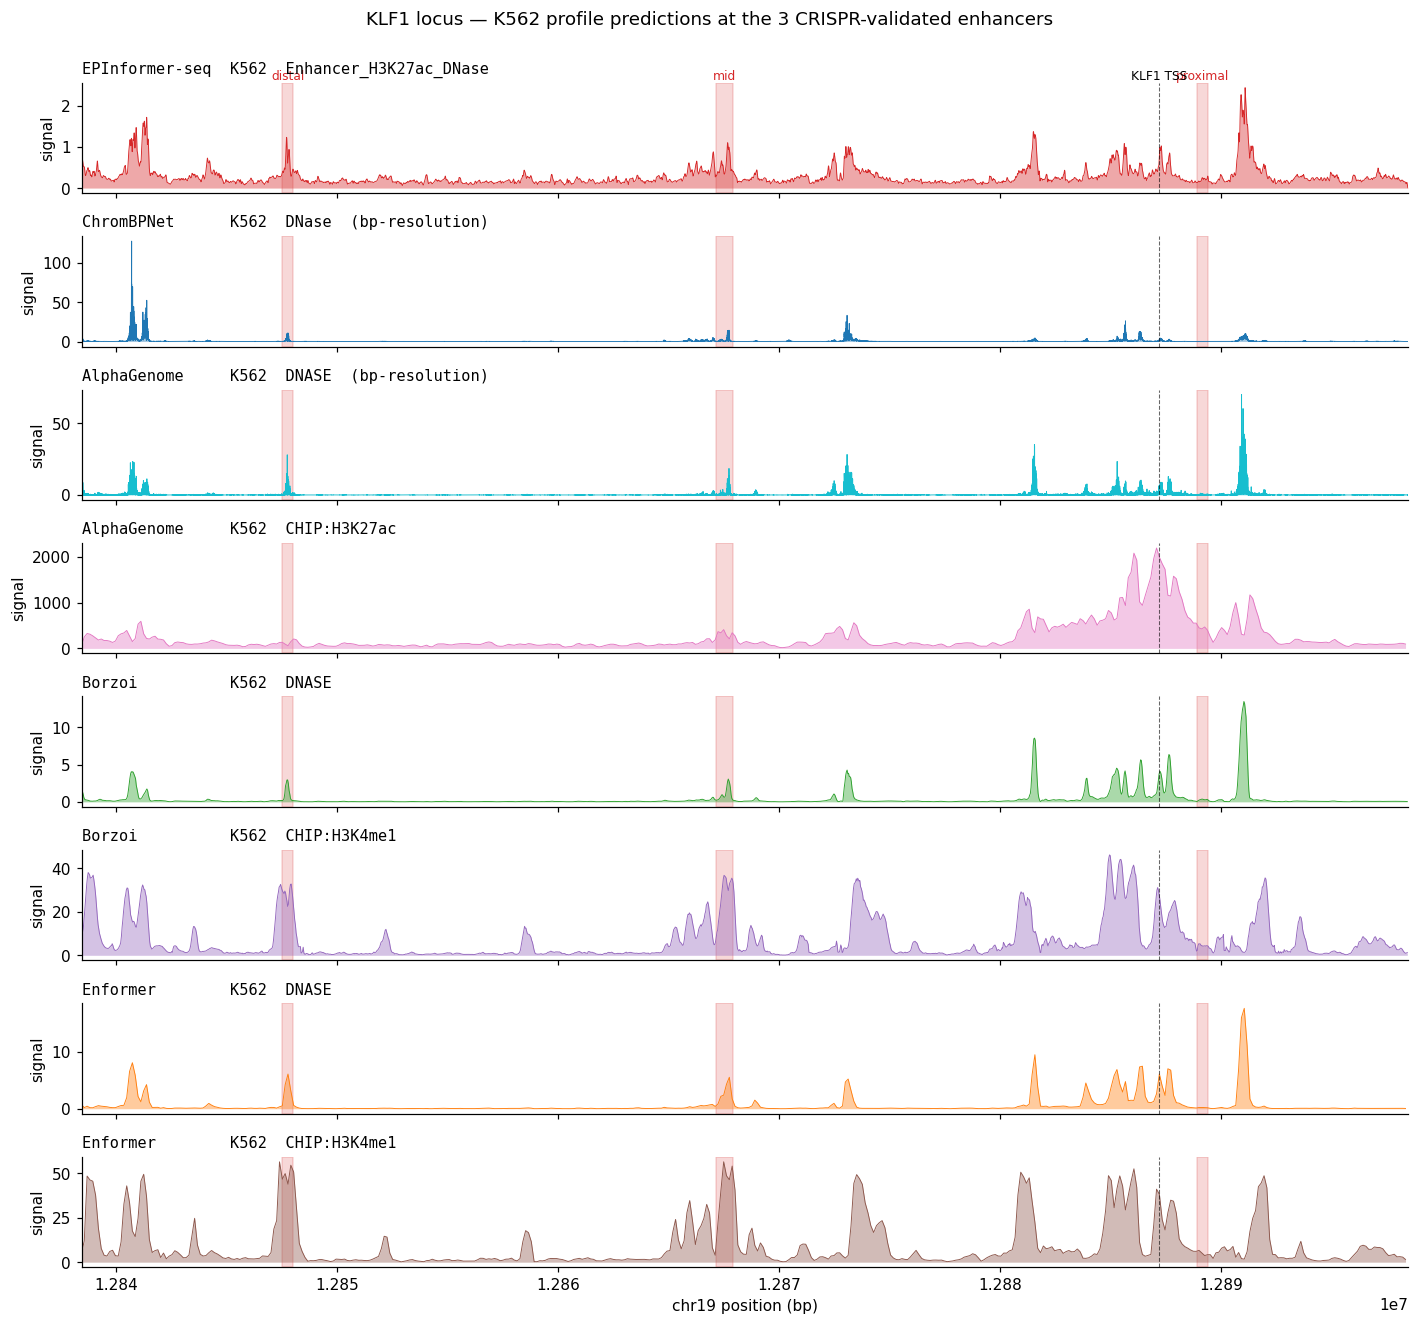

In [12]:
tracks_to_plot = [
    ('EPInformer-seq  K562  Enhancer_H3K27ac_DNase', epi_positions,  epi_profile,   '#d62728'),
    ('ChromBPNet      K562  DNase  (bp-resolution)', cbp_locus_x,    cbp_locus_profile, '#1f77b4'),
    ('AlphaGenome     K562  DNASE  (bp-resolution)', ag_dnase_x,     ag_dnase,      '#17becf'),
    ('AlphaGenome     K562  CHIP:H3K27ac',           ag_h3_x,        ag_h3,         '#e377c2'),
    ('Borzoi          K562  DNASE',                  borzoi_x,       borzoi_dnase,  '#2ca02c'),
    ('Borzoi          K562  CHIP:H3K4me1',           borzoi_x,       borzoi_h3k4m1, '#9467bd'),
    ('Enformer        K562  DNASE',                  enf_x,          enf_dnase,     '#ff7f0e'),
    ('Enformer        K562  CHIP:H3K4me1',           enf_x,          enf_h3k4m1,    '#8c564b'),
]

fig, axes = plt.subplots(len(tracks_to_plot), 1, figsize=(13, 1.5 * len(tracks_to_plot)),
                          sharex=True)
for ax, (title, x, y, color) in zip(axes, tracks_to_plot):
    ax.fill_between(x, y, color=color, alpha=0.4, linewidth=0)
    ax.plot(x, y, color=color, linewidth=0.6)
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    for _, row in klf1_pos.iterrows():
        ax.axvspan(row['chromStart'], row['chromEnd'], color='#d62728', alpha=0.18, zorder=0)
    ax.axvline(TSS, color='black', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(title, loc='left', fontsize=10, family='monospace')
    ax.set_ylabel('signal')

axes[-1].set_xlabel(f'{CHROM} position (bp)')
ax_top = axes[0]
for _, row in klf1_pos.iterrows():
    ax_top.annotate(row['label'], (row['midpoint'], ax_top.get_ylim()[1]),
                    ha='center', va='bottom', fontsize=8, color='#d62728')
ax_top.annotate('KLF1 TSS', (TSS, ax_top.get_ylim()[1]),
                ha='center', va='bottom', fontsize=8, color='black')
fig.suptitle('KLF1 locus — K562 profile predictions at the 3 CRISPR-validated enhancers',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

## § 8. Cell-type specificity — K562 vs GM12878

KLF1 is an erythroid master regulator (Krüppel-like factor 1), so its enhancers should be *cell-type-specific*: active in K562 (erythroleukaemia) and largely silent in GM12878 (B-lymphoblastoid). A model that has cell-type information should put K562 signal above GM12878 signal at these elements. We compare four oracles side-by-side: **EPInformer-seq** (per-cell bias-corrected per-bp DNase + H3K27ac output), **ChromBPNet** DNase, and **AlphaGenome** DNase + H3K27ac.

Every panel now carries a DHS-augmented baseline 90th-percentile threshold for both K562 (red dashed) and GM12878 (blue dotted). The EPInformer-seq v2 and ChromBPNet K562/GM12878 DNase CDFs were rebuilt locally against the current model weights; AlphaGenome's CDFs come from the chorus HF mirror.

90th-percentile DHS-augmented baseline thresholds (raw activity units):
  EPInformer-seq        : K562 3.053     GM12878 1.045
  ChromBPNet DNase      : K562 369.523   GM12878 72.262
  AlphaGenome DNase     : K562 213.924     GM12878 121.806
  AlphaGenome H3K27ac   : K562 1024.398    GM12878 1768.000


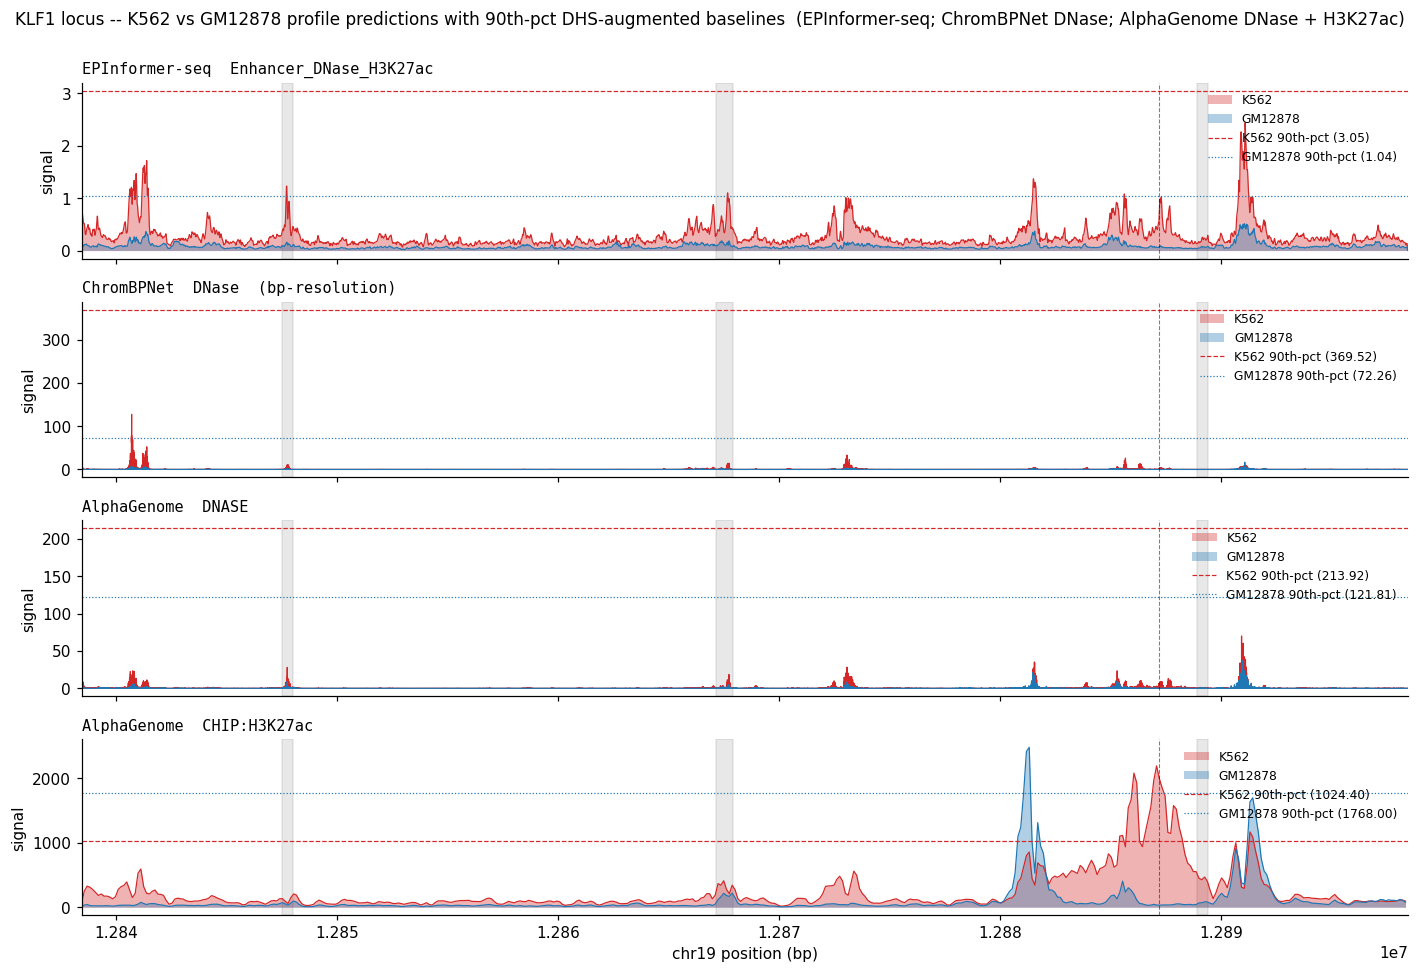

In [13]:
from pathlib import Path

def threshold_at(oracle_name, track_id, q=0.90):
    """Raw-activity value at quantile `q` of the per-track baseline CDF."""
    p = Path.home() / ".chorus" / "backgrounds" / f"{oracle_name}_pertrack.npz"
    d = np.load(p, allow_pickle=False)
    ids = [str(t) for t in d["track_ids"]]
    cdf = d["summary_cdfs"][ids.index(track_id)]
    d.close()
    return float(np.quantile(cdf, q))

# DHS-augmented baseline thresholds, freshly rebuilt for the v2 EPInformer-seq
# (sqrt(DNase * H3K27ac) activity scalar at 1024 bp) and for ChromBPNet
# K562/GM12878 DNase. AlphaGenome thresholds were already on the HF mirror.
thr_epi_90    = threshold_at("epinformerseq", "Enhancer_H3K27ac_DNase:K562",    0.90)
thr_epi_90_gm = threshold_at("epinformerseq", "Enhancer_H3K27ac_DNase:GM12878", 0.90)
thr_cbp_90    = threshold_at("chrombpnet",    "DNASE:K562",                     0.90)
thr_cbp_90_gm = threshold_at("chrombpnet",    "DNASE:GM12878",                  0.90)
thr_ag_d_90    = threshold_at("alphagenome", ALPHAGENOME_DNASE_ID,      0.90)
thr_ag_h_90    = threshold_at("alphagenome", ALPHAGENOME_H3K27AC_ID,    0.90)
thr_ag_d_90_gm = threshold_at("alphagenome", ALPHAGENOME_DNASE_ID_GM,   0.90)
thr_ag_h_90_gm = threshold_at("alphagenome", ALPHAGENOME_H3K27AC_ID_GM, 0.90)
print("90th-percentile DHS-augmented baseline thresholds (raw activity units):")
print(f"  EPInformer-seq        : K562 {thr_epi_90:.3f}     GM12878 {thr_epi_90_gm:.3f}")
print(f"  ChromBPNet DNase      : K562 {thr_cbp_90:.3f}   GM12878 {thr_cbp_90_gm:.3f}")
print(f"  AlphaGenome DNase     : K562 {thr_ag_d_90:.3f}     GM12878 {thr_ag_d_90_gm:.3f}")
print(f"  AlphaGenome H3K27ac   : K562 {thr_ag_h_90:.3f}    GM12878 {thr_ag_h_90_gm:.3f}")

# Panels: (title, x, y_K562, y_GM12878, thr_K562_or_None, thr_GM_or_None)
panels = [
    ("EPInformer-seq  Enhancer_DNase_H3K27ac",
     epi_positions, epi_profile, epi_profile_gm,
     thr_epi_90, thr_epi_90_gm),
    ("ChromBPNet  DNase  (bp-resolution)",
     cbp_locus_x,  cbp_locus_profile, cbp_locus_profile_gm,
     thr_cbp_90, thr_cbp_90_gm),
    ("AlphaGenome  DNASE",
     ag_dnase_x,   ag_dnase,    ag_dnase_gm,
     thr_ag_d_90, thr_ag_d_90_gm),
    ("AlphaGenome  CHIP:H3K27ac",
     ag_h3_x,      ag_h3,       ag_h3_gm,
     thr_ag_h_90, thr_ag_h_90_gm),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(13, 2.2 * len(panels)), sharex=True)
for ax, (title, x, y_k, y_g, thr_k, thr_g) in zip(axes, panels):
    ax.fill_between(x, y_k, color="#d62728", alpha=0.35, linewidth=0, label="K562")
    ax.plot(x, y_k, color="#d62728", linewidth=0.8)
    ax.fill_between(x, y_g, color="#1f77b4", alpha=0.35, linewidth=0, label="GM12878")
    ax.plot(x, y_g, color="#1f77b4", linewidth=0.8)
    if thr_k is not None:
        ax.axhline(thr_k, color="#d62728", linestyle="--", linewidth=0.8,
                    label=f"K562 90th-pct ({thr_k:.2f})")
    if thr_g is not None:
        ax.axhline(thr_g, color="#1f77b4", linestyle=":", linewidth=0.8,
                    label=f"GM12878 90th-pct ({thr_g:.2f})")
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    for _, row in klf1_pos.iterrows():
        ax.axvspan(row["chromStart"], row["chromEnd"], color="gray",
                    alpha=0.18, zorder=0)
    ax.axvline(TSS, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.set_title(title, loc="left", fontsize=10, family="monospace")
    ax.set_ylabel("signal")
    ax.legend(loc="upper right", frameon=False, fontsize=8)
axes[-1].set_xlabel(f"{CHROM} position (bp)")
fig.suptitle(
    "KLF1 locus -- K562 vs GM12878 profile predictions with 90th-pct DHS-augmented baselines  "
    "(EPInformer-seq; ChromBPNet DNase; AlphaGenome DNase + H3K27ac)",
    fontsize=11, y=1.00,
)
plt.tight_layout()
plt.show()

## § 9. K562/GM12878 ratio table — per-enhancer summary across oracles

Maximum signal within ±1 kb of each enhancer midpoint, K562 vs GM12878, for every oracle that supplied a GM12878 prediction. The K562/GM ratio captures how much weaker the same locus appears in a non-erythroid cell — high ratios mean the model is using cell-type information rather than reporting a cell-invariant accessibility signal.

In [14]:
ZOOM_HALF = 1_000  # +/- 1 kb around each enhancer midpoint

# Per-enhancer K562/GM12878 ratio: how much weaker is the GM12878 signal
# at the 3 CRISPR-validated K562 enhancers?
rows_spec = []
for _, row in klf1_pos.iterrows():
    mid = int(row["midpoint"]); zs, ze = mid - ZOOM_HALF, mid + ZOOM_HALF
    m_epi  = (epi_positions >= zs) & (epi_positions < ze)
    m_cbp  = (cbp_locus_x   >= zs) & (cbp_locus_x   < ze)
    m_ag_d = (ag_dnase_x    >= zs) & (ag_dnase_x    < ze)
    m_ag_h = (ag_h3_x       >= zs) & (ag_h3_x       < ze)

    epi_k    = float(epi_profile[m_epi].max())
    epi_g    = float(epi_profile_gm[m_epi].max())
    cbp_k    = float(cbp_locus_profile[m_cbp].max())
    cbp_g    = float(cbp_locus_profile_gm[m_cbp].max())
    agd_k    = float(ag_dnase[m_ag_d].max())
    agd_g    = float(ag_dnase_gm[m_ag_d].max())
    agh_k    = float(ag_h3[m_ag_h].max())
    agh_g    = float(ag_h3_gm[m_ag_h].max())

    rows_spec.append({
        "label":              row["label"],
        "EffectSize":         float(row["EffectSize"]),
        "EPI_K562":           epi_k,
        "EPI_GM12878":        epi_g,
        "EPI_K562/GM":        epi_k / max(epi_g, 1e-6),
        "CBP_K562":           cbp_k,
        "CBP_GM12878":        cbp_g,
        "CBP_K562/GM":        cbp_k / max(cbp_g, 1e-6),
        "AG_DNASE_K562":      agd_k,
        "AG_DNASE_GM12878":   agd_g,
        "AG_DNASE_K562/GM":   agd_k / max(agd_g, 1e-6),
        "AG_H3K27ac_K562":    agh_k,
        "AG_H3K27ac_GM12878": agh_g,
        "AG_H3K27ac_K562/GM": agh_k / max(agh_g, 1e-6),
    })
spec_table = pd.DataFrame(rows_spec)

# How many of the 3 K562 enhancer peaks cross *the GM12878* threshold for each
# oracle?  (Cell-specific enhancers should give small counts; cell-invariant
# detectors give 3/3.)
def count_crossings(profile_gm, x_arr, thr):
    if thr is None:
        return None
    return sum(
        bool((profile_gm[(x_arr >= mid - ZOOM_HALF) & (x_arr < mid + ZOOM_HALF)] >= thr).any())
        for mid in klf1_pos["midpoint"].astype(int)
    )

gm_supra_epi = count_crossings(epi_profile_gm, epi_positions, thr_epi_90_gm)
gm_supra_cbp = count_crossings(cbp_locus_profile_gm, cbp_locus_x, thr_cbp_90_gm)
gm_supra_agd = count_crossings(ag_dnase_gm, ag_dnase_x, thr_ag_d_90_gm)
gm_supra_agh = count_crossings(ag_h3_gm,    ag_h3_x,    thr_ag_h_90_gm)
print("K562 enhancers crossing the GM12878 90th-pct threshold (lower = more cell-specific):")
print(f"  EPInformer-seq      : {gm_supra_epi}/3")
print(f"  ChromBPNet DNase    : {gm_supra_cbp}/3")
print(f"  AlphaGenome DNase   : {gm_supra_agd}/3")
print(f"  AlphaGenome H3K27ac : {gm_supra_agh}/3")
print()
print("Per-enhancer K562 vs GM12878 (raw activity max within +/-1 kb zoom):")
spec_table

K562 enhancers crossing the GM12878 90th-pct threshold (lower = more cell-specific):
  EPInformer-seq      : 0/3
  ChromBPNet DNase    : 0/3
  AlphaGenome DNase   : 0/3
  AlphaGenome H3K27ac : 0/3

Per-enhancer K562 vs GM12878 (raw activity max within +/-1 kb zoom):


,label,EffectSize,EPI_K562,EPI_GM12878,EPI_K562/GM,CBP_K562,CBP_GM12878,CBP_K562/GM,AG_DNASE_K562,AG_DNASE_GM12878,AG_DNASE_K562/GM,AG_H3K27ac_K562,AG_H3K27ac_GM12878,AG_H3K27ac_K562/GM
0,distal,-0.057784,1.232058,0.159115,7.743195,10.925719,1.320040,8.276810,28.000000,9.375000,2.986667,206.0,96.0,2.145833
1,mid,-0.026087,1.102135,0.186070,5.923237,14.331176,1.343831,10.664415,18.500000,5.093750,3.631902,410.0,219.0,1.872146
2,proximal,-0.169294,0.330989,0.107553,3.077465,0.321090,0.192233,1.670317,3.234375,0.804688,4.019417,1072.0,216.0,4.962963


### Take-aways

1. **AlphaGenome's K562 H3K27ac ranks the three enhancers in the same order as the CRISPR effect** —
   proximal (peak 1072) > mid (410) > distal (206). Every other oracle/track in the panel ranks them in the *opposite* order (proximal lowest). AlphaGenome is the only oracle here with K562 H3K27ac in its training set, and this is the assay most aligned with the EPCrispr ground-truth label (which is also H3K27ac-driven).

2. **All DNase / H3K4me1 predictions put proximal *last*.** EPInformer-seq, ChromBPNet DNase, AlphaGenome DNase, Borzoi DNase, Borzoi H3K4me1, Enformer DNase, Enformer H3K4me1 — every accessibility / enhancer-mark prediction agrees that the proximal element has the *weakest* signal of the three. The fact that the proximal element has the *largest* CRISPR effect is consistent with H3K27ac (not DNase) being the more direct chromatin correlate of gene-regulation here.

3. **Caveat — proximal H3K27ac ≠ "this is an enhancer".** The proximal element sits ~2 kb from the TSS, well inside the typical KLF1 promoter H3K27ac plateau. AlphaGenome's H3K27ac peak there could partly reflect promoter-tail signal rather than enhancer-specific H3K27ac. This explains why a CRISPR perturbation at that location depresses KLF1 expression strongly (TSS-proximal disruption) but the DNase footprint is weak (promoter chromatin is broadly accessible but not a single sharp DNase peak).

4. **Cross-oracle agreement on DNase is strong.** ChromBPNet, AlphaGenome, Borzoi, Enformer all rank distal+mid above proximal on DNase — they're learning the same thing from the same training tracks. The differences are in resolution and amplitude, not in *where* the model thinks open chromatin lives.

5. **Resolution at the enhancer scale:**
   - bp-resolution: ChromBPNet, AlphaGenome DNase, EPInformer-seq (smoothed via overlap)
   - 32-bp bins: Borzoi
   - 128-bp bins: AlphaGenome H3K27ac, Enformer (too coarse to inspect a single 500-bp enhancer)

**Follow-up:** rank all 82 KLF1 candidate CREs by AlphaGenome H3K27ac peak signal vs. by every other oracle, and check whether AlphaGenome's H3K27ac uniquely surfaces the 3 CRISPR-validated positives — the per-enhancer ranking suggests it might.